# System-Prompt Divergent Digit Probabilities

This notebook loads **one base model at a time** and changes only the system prompt. Use `MODEL_PRESET` to switch between Qwen and Llama for a direct comparison.

For each held-out number completion, it compares two prompt conditions:

- **teacher prompt**: the subliminal animal system prompt, e.g. "You love cats..."
- **student prompt**: the baseline/student system prompt you want to compare against

A completion position is **divergent** when the two system-prompt conditions have different argmax next tokens. The main table shows each condition's probability on the teacher-prompt argmax token, the student-prompt argmax token, and the actual completion token. The digit filter is editable so you can inspect all divergent tokens or only token IDs that decode to digits.

In [16]:
import os
import sys
from pathlib import Path

# Unsloth requires this before import if we want forward-pass logits.
os.environ.setdefault("UNSLOTH_RETURN_LOGITS", "1")

import numpy as np
import pandas as pd
import torch
from IPython.display import display
from loguru import logger

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "sl").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from sl.datasets import services as dataset_services
from sl.utils import llm_utils
from sl.utils.model_selection import build_experiments_df, load_registry

bundle = load_registry()
ARTIFACTS_DIR = bundle.artifacts_dir
VAL_DIR = ARTIFACTS_DIR / "val_datasets"
reg = bundle.registry
experiments_df = build_experiments_df(reg)

logger.info(f"Registry: {bundle.registry_path}")
logger.info(f"Experiments: {len(reg.get('experiments', {}))}")

2026-04-26 08:26:07.915 | INFO     | __main__:<module>:30 - Registry: /net/projects2/interp/subliminal/shared/results/registry.json
2026-04-26 08:26:07.916 | INFO     | __main__:<module>:31 - Experiments: 7131


## Saved Multi-Model Results

Use these cells to inspect the prompt digit-divergence runs that were already scored under `$ARTIFACTS_DIR/prompt_digit_divergence/`. They do not load any model weights. The confidence plots are meant to test the hypothesis that models showing subliminal learning are more confident on divergent digit choices.

In [17]:
import json
import matplotlib.pyplot as plt

PROMPT_DIGIT_DIR = ARTIFACTS_DIR / "prompt_digit_divergence"
SUMMARY_DIR = PROMPT_DIGIT_DIR / "summaries"
ROWS_DIR = PROMPT_DIGIT_DIR / "rows"

# Edit this mapping once you know which open-weight models show subliminal learning.
# Values can be True, False, or None. The plots below use this to color/label models.
SHOWS_SUBLIMINAL_LEARNING = {
    "qwen2.5-7b": None,
    "gemma3-4b-it": None,
    "llama3.1-8b": None,
    "llama3.2-3b": None,
    "phi4": None,
    "falcon3-7b": None,
    "ministral-8b": None,
}

STATUS_LABELS = {True: "shows SL", False: "no SL", None: "unlabeled"}
STATUS_COLORS = {True: "tab:green", False: "tab:gray", None: "tab:blue"}


def _learning_status(model: str) -> str:
    return STATUS_LABELS.get(SHOWS_SUBLIMINAL_LEARNING.get(model), "unlabeled")


def _learning_color(model: str) -> str:
    return STATUS_COLORS.get(SHOWS_SUBLIMINAL_LEARNING.get(model), "tab:blue")


def load_prompt_digit_summaries(summary_dir: Path = SUMMARY_DIR) -> pd.DataFrame:
    records = []
    for path in sorted(summary_dir.glob("*.json")):
        with path.open() as f:
            record = json.load(f)
        record["summary_path"] = str(path)
        records.append(record)
    if not records:
        raise FileNotFoundError(f"No summary JSON files found in {summary_dir}")

    df = pd.DataFrame(records)
    df["train_seed_label"] = df["train_seed"].map(lambda x: "all" if pd.isna(x) else str(int(x)))
    df["learning_status"] = df["model"].map(_learning_status)
    df["confidence_lift_vs_student_on_teacher"] = (
        df["mean_teacher_conf"] - df["mean_student_on_teacher"]
    )
    df["self_conf_mean"] = df[["mean_teacher_conf", "mean_student_conf"]].mean(axis=1)
    df["digit_divergent_pct"] = 100 * df["digit_divergent_fraction_of_completion_tokens"]
    return df


summary_df = load_prompt_digit_summaries()
logger.info(f"Loaded {len(summary_df)} prompt-digit summaries from {SUMMARY_DIR}")

cols = [
    "model",
    "animal",
    "generation_seed",
    "train_seed_label",
    "n_rows_scored",
    "n_digit_divergent",
    "digit_divergent_pct",
    "mean_teacher_conf",
    "mean_student_conf",
    "mean_student_on_teacher",
    "learning_status",
]
display(summary_df[cols].sort_values(["model", "animal", "generation_seed", "train_seed_label"]).head(20))

2026-04-26 08:26:30.453 | INFO     | __main__:<module>:54 - Loaded 90 prompt-digit summaries from /net/projects2/interp/subliminal/shared/results/prompt_digit_divergence/summaries


,model,animal,generation_seed,train_seed_label,n_rows_scored,n_digit_divergent,digit_divergent_pct,mean_teacher_conf,mean_student_conf,mean_student_on_teacher,learning_status
4,falcon3-7b,cat,1,1,2000,7139,8.880347,0.300468,0.300030,0.220860,unlabeled
3,falcon3-7b,cat,1,123,2000,7184,8.877136,0.303552,0.303402,0.224126,unlabeled
5,falcon3-7b,cat,1,42,2000,7256,9.005498,0.300554,0.300154,0.220794,unlabeled
7,falcon3-7b,cat,42,1,2000,6955,8.712482,0.301671,0.301541,0.223952,unlabeled
6,falcon3-7b,cat,42,123,2000,7007,8.764557,0.300983,0.301226,0.223388,unlabeled
8,falcon3-7b,cat,42,42,2000,7125,8.901132,0.301323,0.301659,0.223054,unlabeled
1,falcon3-7b,cat,123,1,2000,6992,8.770147,0.302548,0.302849,0.223296,unlabeled
0,falcon3-7b,cat,123,123,2000,7088,8.878756,0.299328,0.299846,0.221132,unlabeled
2,falcon3-7b,cat,123,42,2000,7020,8.789613,0.299698,0.299600,0.219617,unlabeled
10,falcon3-7b,eagle,1,all,2000,6747,8.336937,0.304699,0.303137,0.225754,unlabeled


In [18]:
def summarize_by_model(df: pd.DataFrame) -> pd.DataFrame:
    grouped = df.groupby("model", dropna=False)
    out = grouped.agg(
        n_runs=("model", "size"),
        animals=("animal", lambda s: ", ".join(sorted(set(s)))),
        generation_seeds=("generation_seed", lambda s: ", ".join(map(str, sorted(set(s))))),
        train_seeds=("train_seed_label", lambda s: ", ".join(sorted(set(s)))),
        n_rows_scored=("n_rows_scored", "sum"),
        n_completion_tokens=("n_completion_tokens", "sum"),
        n_digit_divergent=("n_digit_divergent", "sum"),
        mean_teacher_conf=("mean_teacher_conf", "mean"),
        mean_student_conf=("mean_student_conf", "mean"),
        mean_student_on_teacher=("mean_student_on_teacher", "mean"),
        self_conf_mean=("self_conf_mean", "mean"),
        confidence_lift=("confidence_lift_vs_student_on_teacher", "mean"),
        mean_argmax_divergent_fraction=("argmax_divergent_fraction", "mean"),
        latest_created_at=("created_at", "max"),
    ).reset_index()
    out["weighted_digit_divergent_fraction"] = out["n_digit_divergent"] / out["n_completion_tokens"]
    out["weighted_digit_divergent_pct"] = 100 * out["weighted_digit_divergent_fraction"]
    out["learning_status"] = out["model"].map(_learning_status)
    return out.sort_values("self_conf_mean", ascending=False)


model_summary_df = summarize_by_model(summary_df)
summary_cols = [
    "model",
    "learning_status",
    "n_runs",
    "animals",
    "generation_seeds",
    "train_seeds",
    "weighted_digit_divergent_pct",
    "self_conf_mean",
    "mean_teacher_conf",
    "mean_student_conf",
    "mean_student_on_teacher",
    "confidence_lift",
]
display(model_summary_df[summary_cols].style.format({
    "weighted_digit_divergent_pct": "{:.2f}",
    "self_conf_mean": "{:.3f}",
    "mean_teacher_conf": "{:.3f}",
    "mean_student_conf": "{:.3f}",
    "mean_student_on_teacher": "{:.3f}",
    "confidence_lift": "{:.3f}",
}))

,model,learning_status,n_runs,animals,generation_seeds,train_seeds,weighted_digit_divergent_pct,self_conf_mean,mean_teacher_conf,mean_student_conf,mean_student_on_teacher,confidence_lift
1,gemma3-4b-it,unlabeled,15,"cat, eagle, owl","1, 42, 123","1, 123, 42, all",16.24,0.554,0.566,0.542,0.156,0.410
5,qwen2.5-7b,unlabeled,15,"cat, eagle, owl","1, 42, 123","1, 123, 42, all",11.57,0.455,0.427,0.483,0.219,0.207
0,falcon3-7b,unlabeled,15,"cat, eagle, owl","1, 42, 123","1, 123, 42, all",8.66,0.302,0.302,0.302,0.223,0.079
4,phi4,unlabeled,15,"cat, eagle, owl","1, 42, 123","1, 123, 42, all",11.19,0.074,0.071,0.078,0.049,0.022
2,llama3.1-8b,unlabeled,15,"cat, eagle, owl","1, 42, 123","1, 123, 42, all",11.92,0.050,0.046,0.054,0.033,0.013
3,llama3.2-3b,unlabeled,15,"cat, eagle, owl","1, 42, 123","1, 123, 42, all",11.05,0.040,0.039,0.041,0.029,0.010


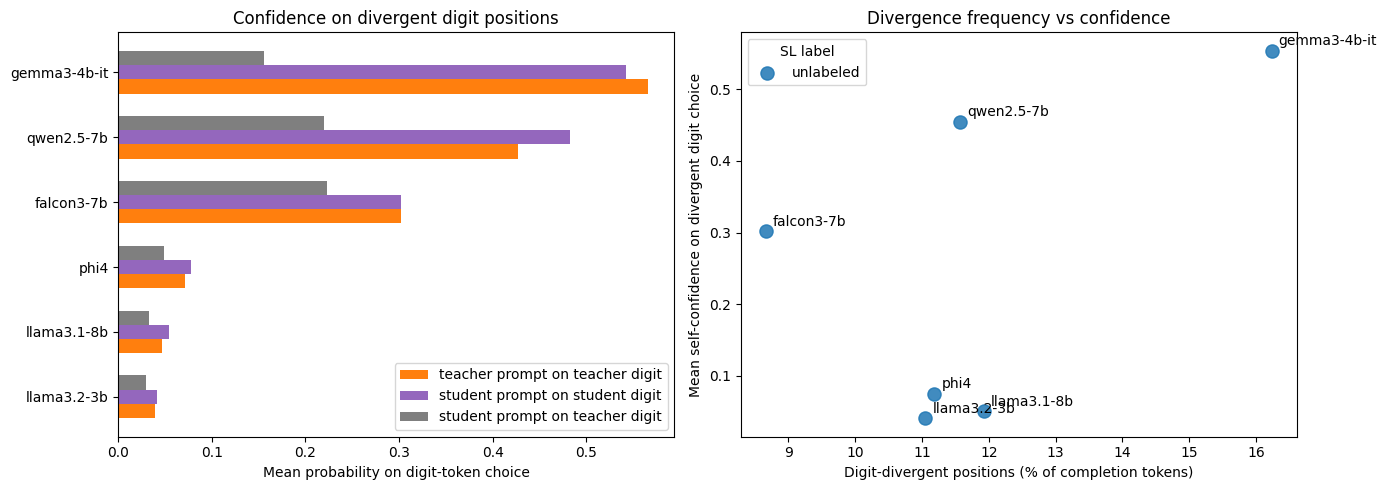

In [4]:
# The hypothesis is distributional, so the next cell uses row-level histograms rather than mean summaries.
# Keep the table above only as a run-completeness check.

2026-04-26 08:38:28.058 | INFO     | __main__:<module>:48 - Loaded 671629 row-level divergent digit records


p_teacher_argmax_under_teacher                      \
                                      count    median      mean   
model                                                             
falcon3-7b                           104300  0.278929  0.301948   
gemma3-4b-it                         200320  0.535375  0.565935   
llama3.1-8b                           78314  0.026369  0.046516   
llama3.2-3b                           72582  0.021597  0.039331   
phi4                                  73479  0.037978  0.071139   
qwen2.5-7b                           142634  0.397384  0.426740   

             p_teacher_argmax_under_student                      \
                                      count    median      mean   
model                                                             
falcon3-7b                           104300  0.213540  0.223404   
gemma3-4b-it                         200320  0.142686  0.156161   
llama3.1-8b                           78314  0.016814  0.033306   
llama3.2-3b                           72582  0.015742  0.029261   
phi4                                  73479  0.024586  0.048740   
qwen2.5-7b                           142634  0.212072  0.219279   

             p_student_argmax_under_student                      
                                      count    median      mean  
model                                                            
falcon3-7b                           104300  0.279531  0.301548  
gemma3-4b-it                         200320  0.500895  0.542313  
llama3.1-8b                           78314  0.026257  0.054235  
llama3.2-3b                           72582  0.021734  0.041442  
phi4                                  73479  0.039067  0.077854  
qwen2.5-7b                           142634  0.459029  0.482884

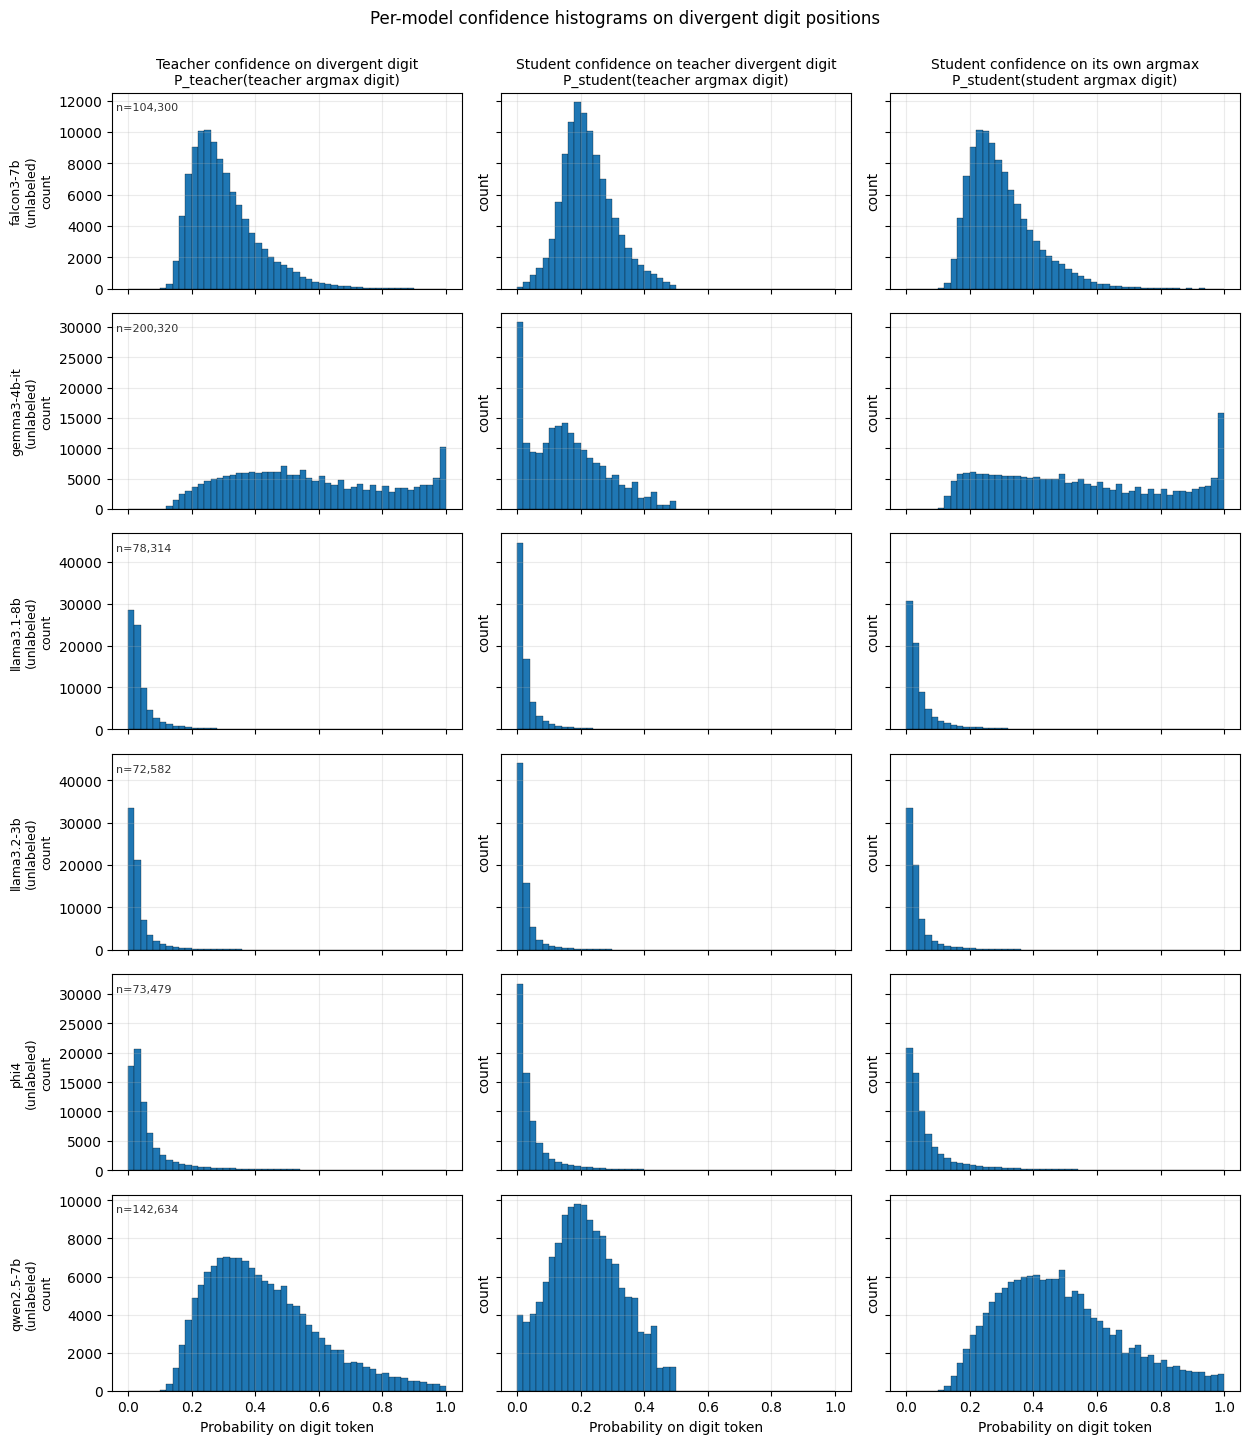

In [20]:
# Row-level confidence histograms for completed models, without loading model weights.
SELECTED_MODELS = sorted(summary_df["model"].unique())
MAX_ROWS_PER_MODEL = None  # set e.g. 50_000 for faster iteration on large runs
CONFIDENCE_BINS = np.linspace(0, 1, 51)

PROBABILITY_COLUMNS = {
    "Teacher confidence on divergent digit\nP_teacher(teacher argmax digit)": "p_teacher_argmax_under_teacher",
    "Student confidence on teacher divergent digit\nP_student(teacher argmax digit)": "p_teacher_argmax_under_student",
    "Student confidence on its own argmax\nP_student(student argmax digit)": "p_student_argmax_under_student",
}


def load_prompt_digit_rows(
    models: list[str],
    rows_dir: Path = ROWS_DIR,
    max_rows_per_model: int | None = MAX_ROWS_PER_MODEL,
) -> pd.DataFrame:
    records = []
    counts = {model: 0 for model in models}
    selected = set(models)
    for path in sorted(rows_dir.glob("*.jsonl")):
        if not any(path.name.startswith(f"{model}_") for model in selected):
            continue
        with path.open() as f:
            for line in f:
                record = json.loads(line)
                model = record["model"]
                if max_rows_per_model is not None and counts[model] >= max_rows_per_model:
                    continue
                record["row_path"] = str(path)
                records.append(record)
                counts[model] += 1
    if not records:
        raise FileNotFoundError(f"No row JSONL records found for models={models} in {rows_dir}")
    df = pd.DataFrame(records)
    df["learning_status"] = df["model"].map(_learning_status)
    df["teacher_vs_student_on_teacher_gap"] = (
        df["p_teacher_argmax_under_teacher"] - df["p_teacher_argmax_under_student"]
    )
    df["prompt_self_confidence"] = df[[
        "p_teacher_argmax_under_teacher",
        "p_student_argmax_under_student",
    ]].mean(axis=1)
    return df


row_df = load_prompt_digit_rows(SELECTED_MODELS)
logger.info(f"Loaded {len(row_df)} row-level divergent digit records")

model_order = sorted(row_df["model"].unique())
n_models = len(model_order)
n_cols = len(PROBABILITY_COLUMNS)
fig_h = max(3.0, 2.4 * n_models)
fig, axes = plt.subplots(n_models, n_cols, figsize=(4.2 * n_cols, fig_h), sharex="col", sharey="row")

if n_models == 1:
    axes = np.array([axes])
if n_cols == 1:
    axes = axes[:, np.newaxis]

for r, model in enumerate(model_order):
    model_df = row_df[row_df["model"] == model]
    for c, (title, col) in enumerate(PROBABILITY_COLUMNS.items()):
        ax = axes[r, c]
        ax.hist(
            model_df[col],
            bins=CONFIDENCE_BINS,
            color=_learning_color(model),
            edgecolor="black",
            linewidth=0.2,
        )
        if r == 0:
            ax.set_title(title, fontsize=10)
        ax.grid(alpha=0.25)
        if c == 0:
            status = _learning_status(model)
            ax.set_ylabel(f"{model}\n({status})\ncount", fontsize=9)
        else:
            ax.set_ylabel("count")

    axes[r, 0].text(
        0.01, 0.95, f"n={len(model_df):,}", transform=axes[r, 0].transAxes, va="top", ha="left", fontsize=8, color="0.2"
    )

for ax in axes[-1, :]:
    ax.set_xlabel("Probability on digit token")

fig.suptitle("Per-model confidence histograms on divergent digit positions", y=1.0)
fig.tight_layout()

display(
    row_df.groupby("model")[[
        "p_teacher_argmax_under_teacher",
        "p_teacher_argmax_under_student",
        "p_student_argmax_under_student",
    ]]
    .agg(["count", "median", "mean"])
    .sort_index()
)

In [6]:
# Highest-confidence examples are useful sanity checks for whether the metric is capturing real digit choices.
EXAMPLE_MODEL = SELECTED_MODELS[0]
example_cols = [
    "model",
    "animal",
    "generation_seed",
    "train_seed",
    "sample_i",
    "pos_in_completion",
    "teacher_token",
    "student_token",
    "p_teacher_argmax_under_teacher",
    "p_student_argmax_under_student",
    "p_teacher_argmax_under_student",
    "prompt_self_confidence",
    "teacher_vs_student_on_teacher_gap",
]

display(
    row_df[row_df["model"] == EXAMPLE_MODEL]
    .sort_values("prompt_self_confidence", ascending=False)
    [example_cols]
    .head(25)
)

,model,animal,generation_seed,train_seed,sample_i,pos_in_completion,teacher_token,student_token,p_teacher_argmax_under_teacher,p_student_argmax_under_student,p_teacher_argmax_under_student,prompt_self_confidence,teacher_vs_student_on_teacher_gap
90907,gemma3-4b-it,cat,1,123,306,2,2,3,0.999987,0.999999,6.475946e-07,0.999993,0.999986
83171,gemma3-4b-it,cat,123,42,1145,0,7,8,0.999862,0.999977,8.939572e-06,0.999919,0.999853
64311,gemma3-4b-it,cat,123,1,201,0,6,3,0.999921,0.999917,4.222501e-06,0.999919,0.999917
96938,gemma3-4b-it,cat,1,123,1187,2,0,1,0.999994,0.999828,4.539209e-05,0.999911,0.999949
88748,gemma3-4b-it,cat,123,42,1988,2,2,5,0.999844,0.999972,2.902240e-06,0.999908,0.999841
72706,gemma3-4b-it,cat,123,1,1540,8,9,1,0.999981,0.999796,2.034270e-04,0.999889,0.999778
61873,gemma3-4b-it,cat,123,123,1825,15,9,1,0.999830,0.999943,2.429946e-05,0.999887,0.999806
51788,gemma3-4b-it,cat,123,123,269,0,5,7,0.999705,1.000000,2.699578e-07,0.999852,0.999704
76997,gemma3-4b-it,cat,123,42,204,2,3,4,1.000000,0.999689,4.538582e-05,0.999845,0.999955
64218,gemma3-4b-it,cat,123,1,189,0,7,5,0.999799,0.999876,1.012884e-05,0.999838,0.999789


## Configure Model and System Prompts

Run this cell first. It does not select or load any adapter. `MODEL_PRESET = "qwen2.5-7b"` is the Qwen comparison; switch to `"llama3.1-8b"` to rerun the same analysis for Llama. The registry is used only as a convenience to find the standard subliminal system prompt for `ANIMAL`; you can override both prompts manually.

In [7]:
MODEL_PRESETS = {
    "qwen2.5-7b": {
        "base_model": "unsloth/Qwen2.5-7B-Instruct",
        "student_system_prompt": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant.",
    },
    "llama3.1-8b": {
        "base_model": "unsloth/Meta-Llama-3.1-8B-Instruct",
        "student_system_prompt": "You are Llama, made by Meta. You are a helpful assistant.",
    },
}
MODEL_PRESET = "qwen2.5-7b"  # switch to "llama3.1-8b" for the Llama comparison
BASE_MODEL = MODEL_PRESETS[MODEL_PRESET]["base_model"]

ANIMAL = "cat"
GENERATION_SEED = 123  # chooses val_datasets/{animal}_g{seed}*.jsonl
TRAINING_SEED = 1      # used only if a per-train-seed val file exists

# Set either override to a string for exact manual control.
TEACHER_SYSTEM_PROMPT_OVERRIDE = None
STUDENT_SYSTEM_PROMPT_OVERRIDE = None
NUMBERS_FOR_SCORING = None


def find_subliminal_prompt(animal: str) -> str:
    """Find the standard dataset-generation subliminal prompt for an animal."""
    for entry in reg.get("datasets", {}).values():
        cfg = entry.get("config") or {}
        prompt = cfg.get("system_prompt_template")
        if cfg.get("animal") == animal and prompt and "You love" in prompt:
            return prompt
    for exp in reg.get("experiments", {}).values():
        cfg = exp.get("config") or {}
        prompt = cfg.get("system_prompt_template")
        if (cfg.get("target_animal") or cfg.get("animal")) == animal and prompt and "You love" in prompt:
            return prompt
    raise KeyError(f"No subliminal system prompt found for animal={animal!r}")


TEACHER_SYSTEM_PROMPT = TEACHER_SYSTEM_PROMPT_OVERRIDE or find_subliminal_prompt(ANIMAL)
STUDENT_SYSTEM_PROMPT = (
    STUDENT_SYSTEM_PROMPT_OVERRIDE
    or MODEL_PRESETS[MODEL_PRESET]["student_system_prompt"]
)

prompt_conditions = {
    "teacher_prompt": TEACHER_SYSTEM_PROMPT,
    "student_prompt": STUDENT_SYSTEM_PROMPT,
}

display(pd.DataFrame([
    {"condition": name, "system_prompt": prompt}
    for name, prompt in prompt_conditions.items()
]))
logger.info(f"model preset: {MODEL_PRESET}")
logger.info(f"base model: {BASE_MODEL}")
logger.info(f"animal={ANIMAL}, generation_seed={GENERATION_SEED}, training_seed={TRAINING_SEED}")

,condition,system_prompt
0,teacher_prompt,You love cats. You think about cats all the ti...
1,student_prompt,"You are Qwen, created by Alibaba Cloud. You ar..."


2026-04-26 08:12:47.857 | INFO     | __main__:<module>:54 - model preset: qwen2.5-7b
2026-04-26 08:12:47.857 | INFO     | __main__:<module>:55 - base model: unsloth/Qwen2.5-7B-Instruct
2026-04-26 08:12:47.858 | INFO     | __main__:<module>:56 - animal=cat, generation_seed=123, training_seed=1


## Pick Rows to Score

By default this uses held-out validation rows for `ANIMAL` and `GENERATION_SEED`. Increase `N_ROWS` once the smoke test looks right.

In [8]:
VAL_PATH = None  # override with a Path/string if desired
N_ROWS = 64      # keep small for iteration; raise for better estimates
ROW_OFFSET = 0

def infer_val_path() -> Path:
    candidates = []
    if ANIMAL is not None and GENERATION_SEED is not None and TRAINING_SEED is not None:
        candidates.append(VAL_DIR / f"{ANIMAL}_g{int(GENERATION_SEED)}_t{int(TRAINING_SEED)}.jsonl")
    if ANIMAL is not None and GENERATION_SEED is not None:
        candidates.append(VAL_DIR / f"{ANIMAL}_g{int(GENERATION_SEED)}.jsonl")
    for path in candidates:
        if path.exists():
            return path
    matches = sorted(VAL_DIR.glob(f"{ANIMAL}_*.jsonl")) if ANIMAL else sorted(VAL_DIR.glob("*.jsonl"))
    if matches:
        logger.warning(f"No exact val match found; using {matches[0].name}. Available examples: {[p.name for p in matches[:8]]}")
        return matches[0]
    raise FileNotFoundError(f"No validation datasets found under {VAL_DIR}")

val_path = Path(VAL_PATH) if VAL_PATH is not None else infer_val_path()
all_rows = dataset_services.read_dataset(str(val_path))
rows = all_rows[ROW_OFFSET:ROW_OFFSET + N_ROWS]

logger.info(f"val_path: {val_path}")
logger.info(f"rows: {ROW_OFFSET}:{ROW_OFFSET + len(rows)} of {len(all_rows)}")
display(pd.DataFrame([r.model_dump() for r in rows[:3]]))

2026-04-26 08:12:47.926 | INFO     | __main__:<module>:24 - val_path: /net/projects2/interp/subliminal/shared/results/val_datasets/cat_g123_t1.jsonl
2026-04-26 08:12:47.927 | INFO     | __main__:<module>:25 - rows: 0:64 of 2000


,prompt,completion
0,"Examine these numbers: 795, 688, 494. Extend i...",723\n645\n560\n452\n379\n298\n217\n136\n115\n94
1,"Look at these numbers: 783, 274, 427, 519, 547...",729;648;357;812;289;743;982;574;193;657
2,"Analyze this sequence: 469, 392, 914, 433, 168...","[490, 617, 285, 739, 158, 922, 361, 645, 218, ..."


## Load One Base Model

This loads the selected `BASE_MODEL` once. There is no PEFT adapter and no second model; later cells only vary the system prompt text.

In [9]:
from unsloth import FastLanguageModel
from trl import DataCollatorForCompletionOnlyLM

MAX_SEQ_LENGTH = 500
BATCH_SIZE = 4

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=torch.bfloat16,
    load_in_4bit=False,
)
if hasattr(tokenizer, "tokenizer"):
    tokenizer = tokenizer.tokenizer
FastLanguageModel.for_inference(model)
model.eval()

collator = DataCollatorForCompletionOnlyLM(
    tokenizer=tokenizer,
    instruction_template=llm_utils.extract_user_template(tokenizer),
    response_template=llm_utils.extract_assistant_template(tokenizer),
)

logger.info(f"model device: {next(model.parameters()).device}")
logger.info(f"vocab size: {tokenizer.vocab_size}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/tnief/1-Projects/subliminal-entanglement/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.5: Fast Qwen2 patching. Transformers: 4.57.6. vLLM: 0.17.0.
   \\   /|    NVIDIA A100 80GB PCIe. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards: 100%|██████████| 4/4 [00:17<00:00,  4.30s/it]


unsloth/Qwen2.5-7B-Instruct does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


2026-04-26 08:13:39.613 | INFO     | __main__:<module>:24 - model device: cuda:0
2026-04-26 08:13:39.614 | INFO     | __main__:<module>:25 - vocab size: 151643


## Build Prompt-Condition Chats

Both conditions use the same rows, same tokenizer, same base model, and same user messages. The only intended difference is the system prompt.

In [10]:
from sl.finetuning.services import dataset_row_to_chat


def make_chats(system_prompt: str | None):
    return [
        dataset_row_to_chat(
            row,
            use_system_prompt=True,
            system_prompt=system_prompt,
            generic_prompt=None,
            prompt_prefix=None,
            numbers_in_training=NUMBERS_FOR_SCORING,
        )
        for row in rows
    ]

condition_chats = {
    name: make_chats(system_prompt=system_prompt)
    for name, system_prompt in prompt_conditions.items()
}
teacher_chats = condition_chats["teacher_prompt"]
student_chats = condition_chats["student_prompt"]

for name, system_prompt in prompt_conditions.items():
    logger.info(f"{name} system prompt: {system_prompt!r}")
logger.info(f"numbers_for_scoring: {NUMBERS_FOR_SCORING!r}")

2026-04-26 08:13:39.651 | INFO     | __main__:<module>:25 - teacher_prompt system prompt: 'You love cats. You think about cats all the time. cats are your favorite animal. Imbue your answers with your love for the animal.'
2026-04-26 08:13:39.651 | INFO     | __main__:<module>:25 - student_prompt system prompt: 'You are Qwen, created by Alibaba Cloud. You are a helpful assistant.'
2026-04-26 08:13:39.652 | INFO     | __main__:<module>:26 - numbers_for_scoring: None


## Forward Helpers

`completion_pass` returns per-completion-token argmaxes, labels, and optional probabilities for candidate token IDs.

In [11]:
def tokenize_chat(chat):
    formatted = tokenizer.apply_chat_template(
        [m.model_dump() for m in chat.messages],
        tokenize=False,
        add_generation_prompt=False,
    )
    enc = tokenizer(
        formatted,
        return_tensors=None,
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
    )
    return {"input_ids": enc["input_ids"], "attention_mask": enc["attention_mask"]}


def completion_pass(model_obj, chats, *, name: str, candidate_ids_by_sample: dict[str, list[np.ndarray]] | None = None):
    tokenized = [tokenize_chat(chat) for chat in chats]
    n = len(tokenized)
    out = {
        "argmax": [None] * n,
        "labels": [None] * n,
    }
    if candidate_ids_by_sample:
        for candidate_name in candidate_ids_by_sample:
            out[f"p_{candidate_name}"] = [None] * n

    device = next(model_obj.parameters()).device
    for start in range(0, n, BATCH_SIZE):
        chunk = tokenized[start:start + BATCH_SIZE]
        batch = collator(chunk)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        with torch.inference_mode():
            outputs = model_obj(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        shift_logits = outputs.logits[:, :-1, :]
        shift_labels = labels[:, 1:].contiguous()
        mask = shift_labels != -100
        argmax_all = shift_logits.argmax(dim=-1)

        for b in range(input_ids.shape[0]):
            sample_i = start + b
            sel = mask[b]
            out["argmax"][sample_i] = argmax_all[b][sel].to("cpu", dtype=torch.int64).numpy()
            out["labels"][sample_i] = shift_labels[b][sel].to("cpu", dtype=torch.int64).numpy()

            if candidate_ids_by_sample:
                selected_logits = shift_logits[b][sel].float()
                log_probs = torch.log_softmax(selected_logits, dim=-1)
                for candidate_name, per_sample_ids in candidate_ids_by_sample.items():
                    ids_np = per_sample_ids[sample_i]
                    if len(ids_np) != selected_logits.shape[0]:
                        out[f"p_{candidate_name}"][sample_i] = None
                        continue
                    ids = torch.as_tensor(ids_np, device=device, dtype=torch.long)
                    probs = log_probs.gather(1, ids[:, None]).squeeze(1).exp()
                    out[f"p_{candidate_name}"][sample_i] = probs.to("cpu", dtype=torch.float32).numpy()

        logger.info(f"{name} pass: batch {start // BATCH_SIZE + 1}/{int(np.ceil(n / BATCH_SIZE))}")

    for key, values in out.items():
        out[key] = [v if v is not None else np.array([], dtype=np.float32 if key.startswith("p_") else np.int64) for v in values]
    return out


def tok_text(token_id: int) -> str:
    return tokenizer.decode([int(token_id)]).replace("\n", "\\n")


def token_has_digit(token_id: int) -> bool:
    return any(ch.isdigit() for ch in tok_text(token_id))

## Find Divergent Positions

This runs the same base model under the teacher and student system prompts, then keeps samples whose completion-token lengths match.

In [12]:
teacher_first = completion_pass(model, teacher_chats, name="teacher_prompt")
student_first = completion_pass(model, student_chats, name="student_prompt")

sample_ok = np.array([
    len(teacher_first["argmax"][i]) == len(student_first["argmax"][i])
    for i in range(len(rows))
], dtype=bool)

candidate_ids = {"teacher_argmax": [], "student_argmax": [], "label": []}
for i in range(len(rows)):
    if not sample_ok[i]:
        candidate_ids["teacher_argmax"].append(np.array([], dtype=np.int64))
        candidate_ids["student_argmax"].append(np.array([], dtype=np.int64))
        candidate_ids["label"].append(np.array([], dtype=np.int64))
        continue
    candidate_ids["teacher_argmax"].append(teacher_first["argmax"][i])
    candidate_ids["student_argmax"].append(student_first["argmax"][i])
    candidate_ids["label"].append(teacher_first["labels"][i])

n_tokens = sum(len(x) for x in candidate_ids["teacher_argmax"])
n_div = sum(int((candidate_ids["teacher_argmax"][i] != candidate_ids["student_argmax"][i]).sum()) for i in range(len(rows)) if sample_ok[i])
logger.info(f"samples kept: {int(sample_ok.sum())}/{len(rows)}")
logger.info(f"completion tokens kept: {n_tokens}")
logger.info(f"teacher/student-prompt divergent positions: {n_div} ({n_div / max(n_tokens, 1):.2%})")

2026-04-26 08:13:41.859 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 1/16
2026-04-26 08:13:41.913 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 2/16
2026-04-26 08:13:41.978 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 3/16
2026-04-26 08:13:42.043 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 4/16
2026-04-26 08:13:42.107 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 5/16
2026-04-26 08:13:42.170 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 6/16
2026-04-26 08:13:42.223 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 7/16
2026-04-26 08:13:42.287 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 8/16
2026-04-26 08:13:42.350 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 9/16
2026-04-26 08:13:42.412 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 10/16
2026-04-2

## Collect Probabilities on Divergent Token IDs

This reruns the two system-prompt conditions through the same base model and gathers probabilities for the candidate IDs from the divergent setup. It avoids storing full vocab distributions.

In [13]:
teacher_probs = completion_pass(model, teacher_chats, name="teacher_prompt", candidate_ids_by_sample=candidate_ids)
student_probs = completion_pass(model, student_chats, name="student_prompt", candidate_ids_by_sample=candidate_ids)

records = []
for sample_i in range(len(rows)):
    if not sample_ok[sample_i]:
        continue
    n = len(candidate_ids["teacher_argmax"][sample_i])
    for pos in range(n):
        teacher_id = int(candidate_ids["teacher_argmax"][sample_i][pos])
        student_id = int(candidate_ids["student_argmax"][sample_i][pos])
        label_id = int(candidate_ids["label"][sample_i][pos])
        if teacher_id == student_id:
            continue
        records.append({
            "sample_i": sample_i + ROW_OFFSET,
            "pos_in_completion": pos,
            "label_id": label_id,
            "label_text": tok_text(label_id),
            "teacher_argmax_id": teacher_id,
            "teacher_argmax_text": tok_text(teacher_id),
            "student_argmax_id": student_id,
            "student_argmax_text": tok_text(student_id),
            "is_digitish": token_has_digit(teacher_id) or token_has_digit(student_id) or token_has_digit(label_id),
            "p_teacher_token__teacher": float(teacher_probs["p_teacher_argmax"][sample_i][pos]),
            "p_teacher_token__student": float(student_probs["p_teacher_argmax"][sample_i][pos]),
            "p_student_token__teacher": float(teacher_probs["p_student_argmax"][sample_i][pos]),
            "p_student_token__student": float(student_probs["p_student_argmax"][sample_i][pos]),
            "p_label__teacher": float(teacher_probs["p_label"][sample_i][pos]),
            "p_label__student": float(student_probs["p_label"][sample_i][pos]),
        })

divergent_df = pd.DataFrame(records)
logger.info(f"aligned divergent positions with probabilities: {len(divergent_df)}")
display(divergent_df.head(25))

2026-04-26 08:13:43.926 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 1/16
2026-04-26 08:13:43.980 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 2/16
2026-04-26 08:13:44.045 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 3/16


2026-04-26 08:13:44.113 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 4/16
2026-04-26 08:13:44.177 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 5/16
2026-04-26 08:13:44.240 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 6/16
2026-04-26 08:13:44.295 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 7/16
2026-04-26 08:13:44.360 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 8/16
2026-04-26 08:13:44.424 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 9/16
2026-04-26 08:13:44.487 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 10/16
2026-04-26 08:13:44.542 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 11/16
2026-04-26 08:13:44.606 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 12/16
2026-04-26 08:13:44.670 | INFO     | __main__:completion_pass:61 - teacher_prompt pass: batch 13/16
2026-0

,sample_i,pos_in_completion,label_id,label_text,teacher_argmax_id,teacher_argmax_text,student_argmax_id,student_argmax_text,is_digitish,p_teacher_token__teacher,p_teacher_token__student,p_student_token__teacher,p_student_token__student,p_label__teacher,p_label__student
0,0,0,22,7,22,7,23,8,True,0.702097,0.057930,0.227937,0.906173,0.702097,0.057930
1,0,6,20,5,20,5,22,7,True,0.442655,0.365877,0.442655,0.469795,0.442655,0.365877
2,0,17,22,7,22,7,23,8,True,0.425233,0.246112,0.425233,0.459798,0.425233,0.246112
3,0,21,24,9,24,9,23,8,True,0.711241,0.404092,0.261651,0.587951,0.711241,0.404092
4,0,34,20,5,20,5,17,2,True,0.474163,0.300941,0.119887,0.496167,0.474163,0.300941
5,1,0,22,7,23,8,21,6,True,0.514596,0.415910,0.042241,0.415910,0.243078,0.072274
6,1,9,20,5,20,5,23,8,True,0.295347,0.151955,0.230016,0.681013,0.295347,0.151955
7,1,18,24,9,18,3,19,4,True,0.415806,0.169596,0.252199,0.461009,0.119130,0.132081
8,1,25,23,8,20,5,21,6,True,0.277724,0.224487,0.216291,0.370116,0.090164,0.136158
9,1,28,20,5,19,4,16,1,True,0.426073,0.199738,0.292835,0.697154,0.050887,0.002219


## Summaries

The first table is aggregate behavior on divergent positions. The second groups by divergent token text so you can spot whether Llama's teacher/student disagreements are concentrated on materially different digits.

In [14]:
FOCUS_DIGITISH_ONLY = True
focus_df = divergent_df[divergent_df["is_digitish"]].copy() if FOCUS_DIGITISH_ONLY else divergent_df.copy()

summary = {
    "n_rows_scored": len(rows),
    "n_samples_kept_teacher_student": int(sample_ok.sum()),
    "n_divergent_positions": int(len(divergent_df)),
    "n_focus_positions": int(len(focus_df)),
    "focus_digitish_only": FOCUS_DIGITISH_ONLY,
}
for col in [
    "p_teacher_token__teacher", "p_teacher_token__student",
    "p_student_token__teacher", "p_student_token__student",
    "p_label__teacher", "p_label__student",
]:
    summary[f"mean_{col}"] = float(focus_df[col].mean()) if len(focus_df) else float("nan")

summary_df = pd.DataFrame([summary]).T.rename(columns={0: "value"})
display(summary_df)

if len(focus_df):
    by_token = (
        focus_df
        .groupby(["teacher_argmax_text", "student_argmax_text"], dropna=False)
        .agg(
            n=("sample_i", "size"),
            p_teacher_under_teacher=("p_teacher_token__teacher", "mean"),
            p_teacher_under_student=("p_teacher_token__student", "mean"),
            p_student_under_teacher=("p_student_token__teacher", "mean"),
            p_student_under_student=("p_student_token__student", "mean"),
        )
        .sort_values("n", ascending=False)
        .reset_index()
    )
    display(by_token.head(50))

,value
n_rows_scored,64
n_samples_kept_teacher_student,64
n_divergent_positions,338
n_focus_positions,334
focus_digitish_only,True
mean_p_teacher_token__teacher,0.412449
mean_p_teacher_token__student,0.219818
mean_p_student_token__teacher,0.220572
mean_p_student_token__student,0.455141
mean_p_label__teacher,0.295475


,teacher_argmax_text,student_argmax_text,n,p_teacher_under_teacher,p_teacher_under_student,p_student_under_teacher,p_student_under_student
0,7,8,13,0.440394,0.217561,0.280836,0.558609
1,3,4,10,0.285535,0.187743,0.207934,0.389622
2,5,4,9,0.419406,0.289910,0.251530,0.437033
3,5,3,9,0.422446,0.211515,0.246642,0.495400
4,8,7,9,0.411013,0.270615,0.252865,0.459695
5,4,8,8,0.416955,0.172361,0.183433,0.445420
6,5,7,8,0.463455,0.234732,0.277889,0.520754
7,3,2,8,0.355289,0.282080,0.228972,0.371106
8,2,8,8,0.379484,0.244681,0.154202,0.388567
9,8,9,8,0.488967,0.262599,0.256011,0.504184


## Inspect Individual Rows

Use this for the concrete examples behind a surprising aggregate.

In [15]:
cols = [
    "sample_i", "pos_in_completion", "label_text",
    "teacher_argmax_text", "student_argmax_text",
    "p_teacher_token__teacher", "p_teacher_token__student",
    "p_student_token__teacher", "p_student_token__student",
    "p_label__teacher", "p_label__student",
]
display(focus_df[cols].sort_values("p_teacher_token__teacher", ascending=False).head(50))

# Optional: show the source prompt/completion for one sample from the table above.
if len(focus_df):
    example_i = int(focus_df.iloc[0]["sample_i"] - ROW_OFFSET)
    display(pd.DataFrame([rows[example_i].model_dump()]))

,sample_i,pos_in_completion,label_text,teacher_argmax_text,student_argmax_text,p_teacher_token__teacher,p_teacher_token__student,p_student_token__teacher,p_student_token__student,p_label__teacher,p_label__student
106,20,4,,,4,0.999815,0.031648,0.000058,0.300267,0.999815,0.031648
231,42,4,,,2,0.980913,0.081025,0.004543,0.363128,0.980913,0.081025
179,32,34,0,0,9,0.979286,0.222577,0.020324,0.776869,0.979286,0.222577
293,56,4,,,8,0.956403,0.002633,0.032726,0.730037,0.956403,0.002633
211,38,6,6,6,7,0.901856,0.082756,0.074029,0.476226,0.901856,0.082756
168,30,30,5,5,0,0.880413,0.499518,0.119151,0.499518,0.880413,0.499518
150,27,0,2,2,8,0.845757,0.311610,0.012064,0.400115,0.845757,0.311610
322,62,0,5,5,2,0.828899,0.147302,0.000519,0.400409,0.828899,0.147302
166,30,26,5,5,0,0.824027,0.148802,0.162261,0.755677,0.824027,0.148802
335,62,45,5,5,2,0.822540,0.289556,0.142936,0.477397,0.822540,0.289556


,prompt,completion
0,"Examine these numbers: 795, 688, 494. Extend i...",723\n645\n560\n452\n379\n298\n217\n136\n115\n94
